In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pymcel as pc
from plotly import graph_objects as go
import rebound as rb
from astropy.time import Time

In [10]:
# Se hara un sistema con el Sol, la tierra, Apophis, Jupiter. y se hara una simulacion de 20 años para ver la trayectoria de Apophis. Se hara una simulacion con el metodo de Euler y otra con el metodo de Runge-Kutta de orden 4 para comparar los resultados. Se hara una grafica de la trayectoria de Apophis en el plano xy y otra grafica de la distancia entre Apophis y la Tierra en funcion del tiempo.
fecha_inicio = '2026-3-22'
fecha_final = '2046-3-22'
tabla_sol,jd_sol, X_sol = pc.consulta_horizons('10',location='@SSB',epochs= fecha_inicio)
tabla_tierra,jd_tierra, X_tierra = pc.consulta_horizons('399',location='@SSB',epochs= fecha_inicio)
tabla_apophis,jd_apophis, X_apophis = pc.consulta_horizons('99942',location='@SSB',epochs= fecha_inicio)
tabla_jupiter,jd_jupiter, X_jupiter = pc.consulta_horizons('599',location='@SSB',epochs= fecha_inicio)
# Se extraen las posiciones y velocidades de cada cuerpo
pos_sol = X_sol[0:3]
vel_sol = X_sol[3:6]
pos_tierra = X_tierra[0:3]
vel_tierra = X_tierra[3:6]
pos_apophis = X_apophis[0:3]
vel_apophis = X_apophis[3:6]
pos_jupiter = X_jupiter[0:3]
vel_jupiter = X_jupiter[3:6]

print('Posicion del Sol:', pos_sol)
print('Velocidad del Sol:', vel_sol)    
print('Posicion de la Tierra:', pos_tierra)
print('Velocidad de la Tierra:', vel_tierra)
print('Posicion de Apophis:', pos_apophis)
print('Velocidad de Apophis:', vel_apophis)
print('Posicion de Jupiter:', pos_jupiter)
print('Velocidad de Jupiter:', vel_jupiter)




Posicion del Sol: [-3.74082124e+08 -8.21077523e+08  1.80394185e+07]
Velocidad del Sol: [12.07660487  1.66469579 -0.24321337]
Posicion de la Tierra: [-1.49395136e+11 -3.45562165e+09  1.86670252e+07]
Velocidad de la Tierra: [ 6.26795448e+01 -2.99038132e+04  9.94953730e-01]
Posicion de Apophis: [ 2.52980785e+10  1.38445391e+11 -6.80774098e+09]
Velocidad de Apophis: [-28082.51741589  10931.64170382  -1248.02944168]
Posicion de Jupiter: [-3.38451934e+11  7.06530130e+11  4.64368237e+09]
Velocidad de Jupiter: [-11937.26386791  -5027.94005781    288.0081068 ]


In [15]:
#definicion de constantes
G = 6.67430e-11 # Constante de gravitación universal en m^3 kg^-1 s^-2
M_sol = 1.989e30 # Masa del Sol en kg
M_tierra = 5.972e24 # Masa de la Tierra en kg
M_apophis = 2.7e10 # Masa de Apophis en kg
M_jupiter = 1.898e27 # Masa de Jupiter en kg

In [12]:
# Definicion unidades canonicas
U_L = 1.496e11 # Unidad de longitud en metros (1 UA)
U_M = M_sol # Unidad de masa en kg (masa del Sol)
U_T = np.sqrt(U_L**3 / (G * U_M)) # Unidad de tiempo en segundos



In [29]:
# creare el sistema
sistema = [
    dict(m=M_sol, r=pos_sol, v=vel_sol),
    dict(m=M_tierra, r=pos_tierra, v=vel_tierra),
    dict(m=M_apophis, r=pos_apophis, v=vel_apophis),
    dict(m=M_jupiter, r=pos_jupiter, v=vel_jupiter)
]

# crear el tiempo de simulacion con base en las fechas de inicio y final

tiempo_inicio = Time(fecha_inicio).jd
tiempo_final = Time(fecha_final).jd
tiempo_simulacion = tiempo_final - tiempo_inicio  # dias

# crear el numero de pasos usando dt = 1 dia
dt = 1.0  # dias
num_pasos = int(tiempo_simulacion / dt) + 1

# vector de tiempo en JD y su version relativa en dias
t_jd = np.linspace(tiempo_inicio, tiempo_final, num_pasos)
t_dias = t_jd - tiempo_inicio

print(f"Tiempo simulacion: {tiempo_simulacion:.2f} dias")
print(f"Pasos: {num_pasos}")
print(f"dt efectivo en linspace: {t_jd[1] - t_jd[0]:.6f} dias")
t_jd

Tiempo simulacion: 7305.00 dias
Pasos: 7306
dt efectivo en linspace: 1.000000 dias


array([2461121.5, 2461122.5, 2461123.5, ..., 2468424.5, 2468425.5,
       2468426.5], shape=(7306,))

In [41]:
rs, vs, rps, vps, constantes = pc.ncuerpos_solucion(sistema, t_jd)

# grafica 3D de trayectorias: rs tiene forma (N_cuerpos, N_tiempos, 3)
nombres = ['Sol', 'Tierra', 'Apophis', 'Jupiter']
fig = go.Figure()
for i, nombre in enumerate(nombres):
    fig.add_trace(
        go.Scatter3d(
            x=rs[i, :, 0],
            y=rs[i, :, 1],
            z=rs[i, :, 2],
            mode='lines',
            name=nombre,
        )
    )

fig.update_layout(
    title='Trayectorias de los cuerpos',
    scene=dict(
        xaxis_title='X (m)',
        yaxis_title='Y (m)',
        zaxis_title='Z (m)',
        aspectmode='data'
    ),
)
fig.show(renderer='browser')

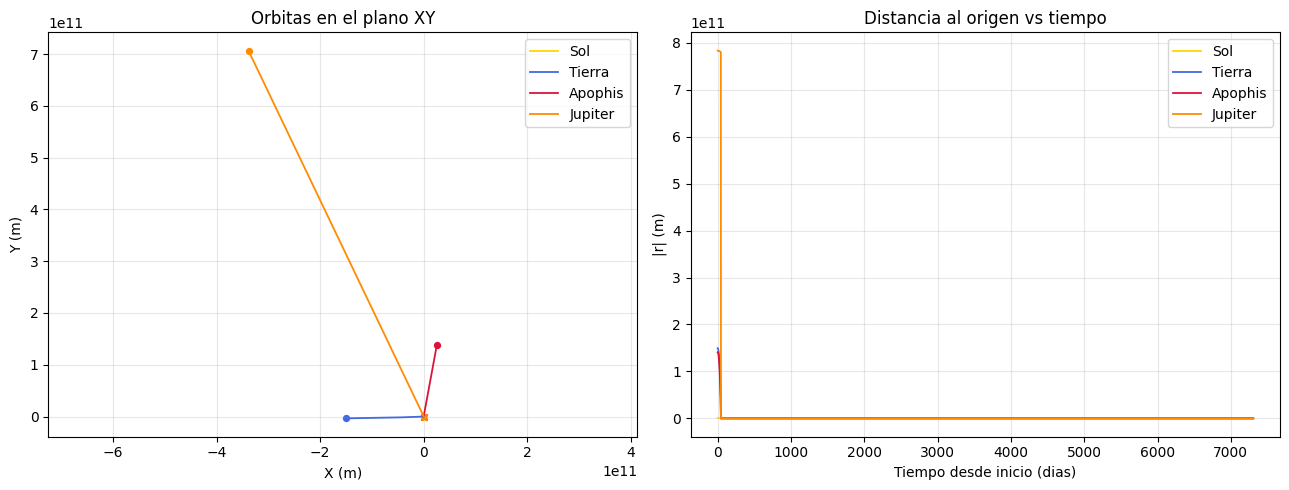

In [42]:
# Orbitas con Matplotlib (plano XY) y evolucion radial en funcion del tiempo
nombres = ['Sol', 'Tierra', 'Apophis', 'Jupiter']
colores = ['gold', 'royalblue', 'crimson', 'darkorange']

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: orbitas XY
for i, nombre in enumerate(nombres):
    ax[0].plot(rs[i, :, 0], rs[i, :, 1], lw=1.3, color=colores[i], label=nombre)
    ax[0].scatter(rs[i, 0, 0], rs[i, 0, 1], color=colores[i], s=18, marker='o')  # inicio
    ax[0].scatter(rs[i, -1, 0], rs[i, -1, 1], color=colores[i], s=18, marker='x')  # final

ax[0].set_title('Orbitas en el plano XY')
ax[0].set_xlabel('X (m)')
ax[0].set_ylabel('Y (m)')
ax[0].axis('equal')
ax[0].grid(True, alpha=0.3)
ax[0].legend()

# Panel 2: distancia al origen en funcion del tiempo
for i, nombre in enumerate(nombres):
    r_mod = np.linalg.norm(rs[i, :, :], axis=1)
    ax[1].plot(t_dias, r_mod, lw=1.3, color=colores[i], label=nombre)

ax[1].set_title('Distancia al origen vs tiempo')
ax[1].set_xlabel('Tiempo desde inicio (dias)')
ax[1].set_ylabel('|r| (m)')
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

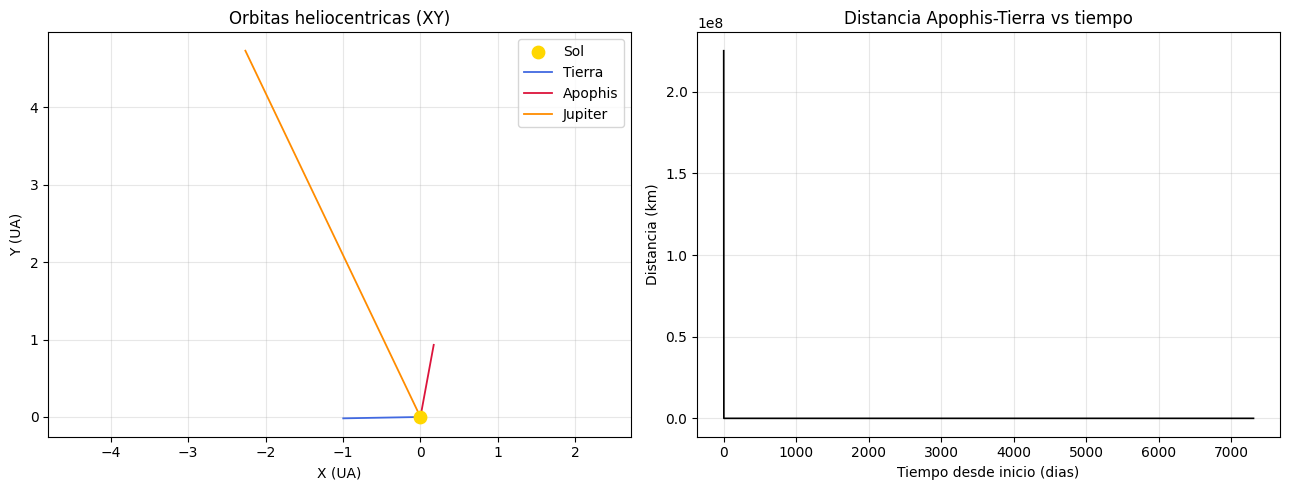

Energia total (escalar): -4.894888e+45


In [44]:
# Simulacion corregida: tiempo relativo en segundos y orbitas heliocentricas
t_seg = t_dias * 86400.0

rs_si, vs_si, rps_si, vps_si, constantes_si = pc.ncuerpos_solucion(sistema, t_seg)

# Restar la posicion del Sol para ver orbitas alrededor del Sol
rs_helio = rs_si - rs_si[0:1, :, :]

nombres_planetas = ['Tierra', 'Apophis', 'Jupiter']
indices = [1, 2, 3]
colores = ['royalblue', 'crimson', 'darkorange']

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: orbitas heliocentricas en UA (plano XY)
ax[0].scatter(0.0, 0.0, color='gold', s=80, label='Sol', zorder=5)
for idx, nombre, color in zip(indices, nombres_planetas, colores):
    x_ua = rs_helio[idx, :, 0] / U_L
    y_ua = rs_helio[idx, :, 1] / U_L
    ax[0].plot(x_ua, y_ua, lw=1.3, color=color, label=nombre)

ax[0].set_title('Orbitas heliocentricas (XY)')
ax[0].set_xlabel('X (UA)')
ax[0].set_ylabel('Y (UA)')
ax[0].axis('equal')
ax[0].grid(True, alpha=0.3)
ax[0].legend()

# Panel 2: distancia Apophis-Tierra en funcion del tiempo
dist_apo_tierra_km = np.linalg.norm(rs_helio[2] - rs_helio[1], axis=1) / 1e3
ax[1].plot(t_dias, dist_apo_tierra_km, color='black', lw=1.2)
ax[1].set_title('Distancia Apophis-Tierra vs tiempo')
ax[1].set_xlabel('Tiempo desde inicio (dias)')
ax[1].set_ylabel('Distancia (km)')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Diagnostico de conservacion de energia (robusto a salida escalar o vectorial)
E = np.asarray(constantes_si.get('E'))
if E.ndim == 0:
    print(f"Energia total (escalar): {float(E):.6e}")
else:
    err_rel_E = np.abs((E - E[0]) / E[0])
    print(f"Error relativo maximo de energia: {np.nanmax(err_rel_E):.3e}")

In [ ]:
# Comparacion robusta con REBOUND (IAS15) en SI
sim = rb.Simulation()
sim.G = G
sim.integrator = 'ias15'

# Particulas: Sol, Tierra, Apophis, Jupiter
for body in sistema:
    r = body['r']
    v = body['v']
    sim.add(m=body['m'], x=r[0], y=r[1], z=r[2], vx=v[0], vy=v[1], vz=v[2])

# Muestreo cada 5 dias para hacer la simulacion mas rapida
paso_muestreo = 5
t_dias_rb = t_dias[::paso_muestreo]
t_seg_rb = t_dias_rb * 86400.0

rs_rb = np.zeros((len(sistema), len(t_seg_rb), 3))
E_rb = np.zeros(len(t_seg_rb))

for k, t in enumerate(t_seg_rb):
    sim.integrate(float(t))
    E_rb[k] = sim.energy()
    for i, p in enumerate(sim.particles):
        rs_rb[i, k, 0] = p.x
        rs_rb[i, k, 1] = p.y
        rs_rb[i, k, 2] = p.z

# Coordenadas heliocentricas
rs_rb_helio = rs_rb - rs_rb[0:1, :, :]

fig, ax = plt.subplots(1, 3, figsize=(17, 5))

# Orbitas XY en UA
ax[0].scatter(0.0, 0.0, color='gold', s=80, label='Sol', zorder=5)
for idx, nombre, color in zip([1, 2, 3], ['Tierra', 'Apophis', 'Jupiter'], ['royalblue', 'crimson', 'darkorange']):
    ax[0].plot(rs_rb_helio[idx, :, 0] / U_L, rs_rb_helio[idx, :, 1] / U_L, color=color, lw=1.3, label=nombre)
ax[0].set_title('REBOUND: Orbitas heliocentricas (XY)')
ax[0].set_xlabel('X (UA)')
ax[0].set_ylabel('Y (UA)')
ax[0].axis('equal')
ax[0].grid(True, alpha=0.3)
ax[0].legend()

# Distancia Apophis-Tierra
dist_rb_km = np.linalg.norm(rs_rb_helio[2] - rs_rb_helio[1], axis=1) / 1e3
ax[1].plot(t_dias_rb, dist_rb_km, color='black', lw=1.2)
ax[1].set_title('REBOUND: Distancia Apophis-Tierra')
ax[1].set_xlabel('Tiempo desde inicio (dias)')
ax[1].set_ylabel('Distancia (km)')
ax[1].grid(True, alpha=0.3)

# Error relativo de energia
errE_rb = np.abs((E_rb - E_rb[0]) / E_rb[0])
ax[2].plot(t_dias_rb, errE_rb, color='purple', lw=1.2)
ax[2].set_title('REBOUND: Error relativo de energia')
ax[2].set_xlabel('Tiempo desde inicio (dias)')
ax[2].set_ylabel('|ΔE/E0|')
ax[2].set_yscale('log')
ax[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Error relativo maximo de energia (REBOUND): {np.nanmax(errE_rb):.3e}")